============================================================
LOGISTIC REGRESSION - DIABETES PREDICTION
============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

============================================================
1. DATA EXPLORATION
============================================================

In [3]:
# Load dataset
df = pd.read_csv("diabetes.csv")

In [4]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

DATASET INFORMATION


In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(768, 9)


In [7]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [8]:
print("\nData types:")
print(df.dtypes)


Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [9]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000

In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


============================================================
2. HANDLE ZERO VALUES REPRESENTING MISSING VALUES
============================================================

In the diabetes dataset, zero is not medically meaningful
for these columns and can represent missing measurements.

In [11]:
columns_with_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

In [12]:
df[columns_with_missing] = df[columns_with_missing].replace(
    0, np.nan
)

In [13]:
print("\nMissing values after replacing invalid zeros:")
print(df.isnull().sum())


Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


============================================================
3. DATA VISUALIZATION
============================================================

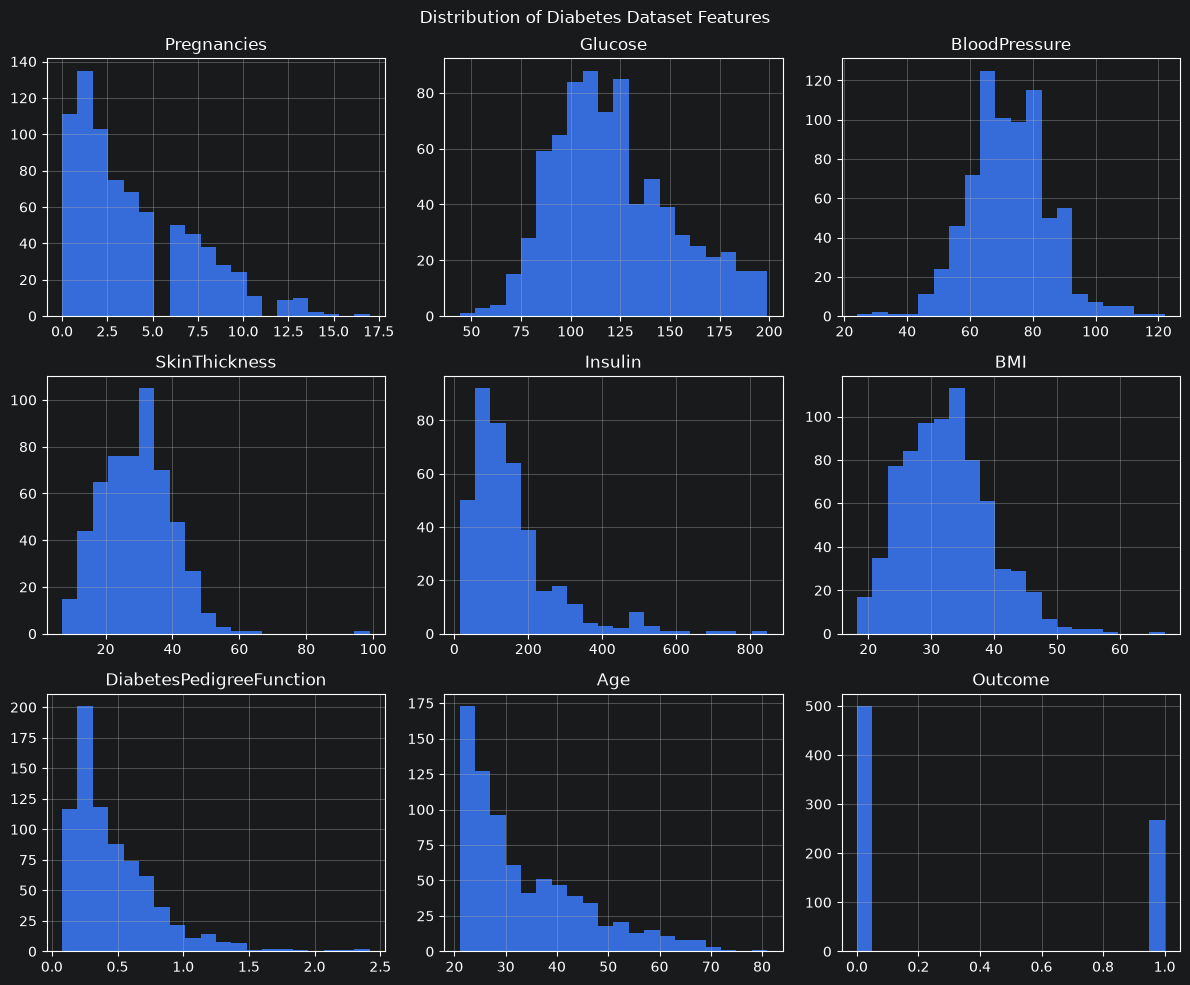

In [14]:
# Histograms
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribution of Diabetes Dataset Features")
plt.tight_layout()
plt.show()

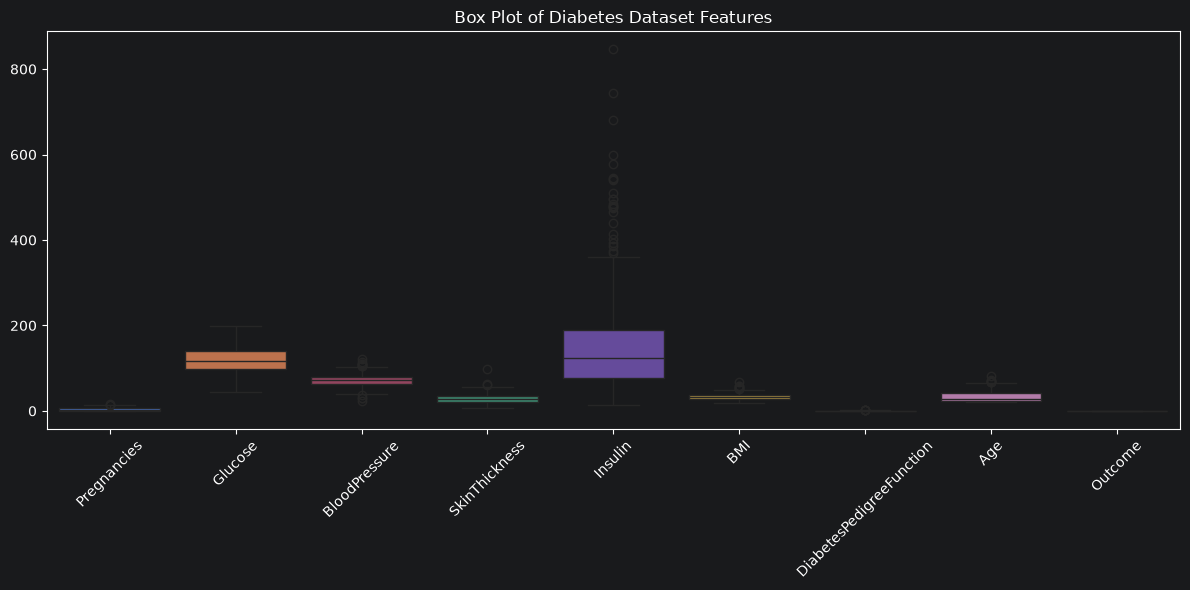

In [15]:
# Box plots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of Diabetes Dataset Features")
plt.tight_layout()
plt.show()

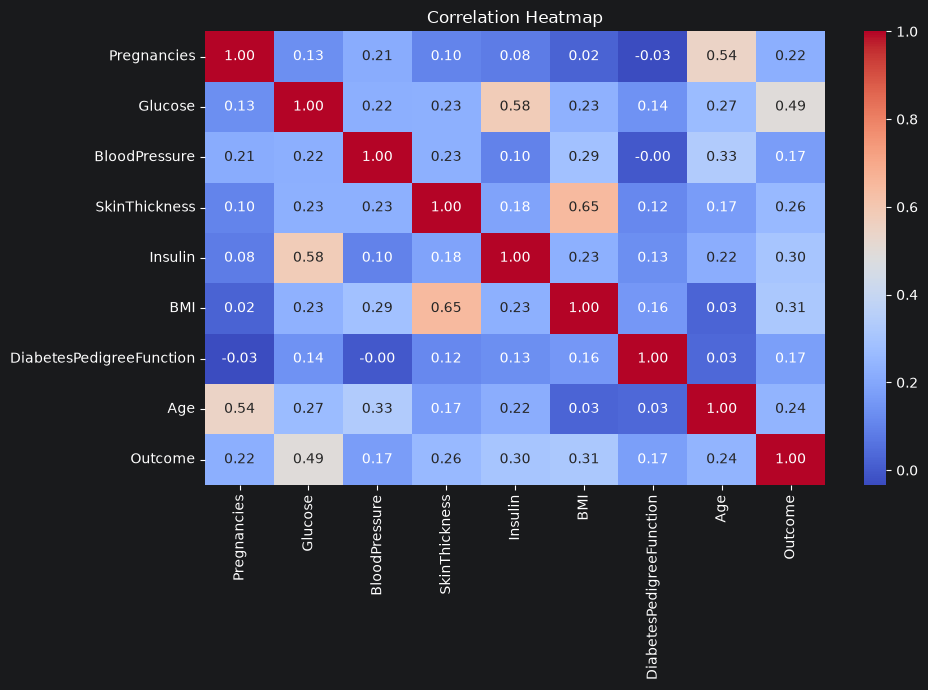

In [16]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

============================================================
4. PREPARE FEATURES AND TARGET
============================================================

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [18]:
print("\nFeature columns:")
print(X.columns.tolist())


Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [19]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


============================================================
5. TRAIN-TEST SPLIT
============================================================

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (614, 8)
Testing data shape: (154, 8)


============================================================
6. BUILD LOGISTIC REGRESSION PIPELINE
============================================================

In [22]:
model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(max_iter=1000)
    )
])

============================================================
7. TRAIN MODEL
============================================================

In [23]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For str

In [24]:
print("\nModel training completed successfully.")


Model training completed successfully.


============================================================
8. MODEL PREDICTION
============================================================

In [25]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

============================================================
9. MODEL EVALUATION
============================================================

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

In [27]:
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)


MODEL EVALUATION


In [28]:
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1-Score  : 0.5455
ROC-AUC   : 0.8130


In [29]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



============================================================
10. CONFUSION MATRIX
============================================================

In [30]:
cm = confusion_matrix(y_test, y_pred)

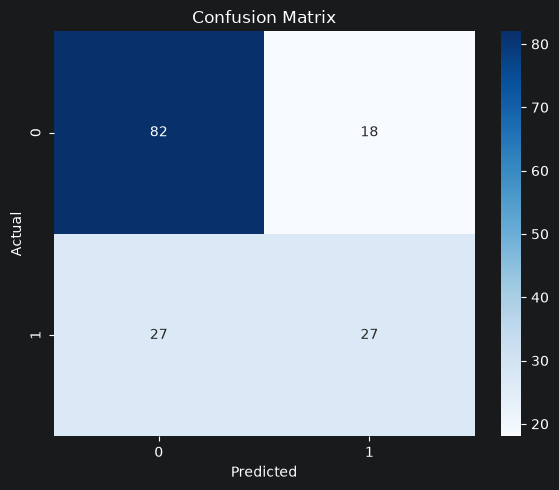

In [31]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

============================================================
11. ROC CURVE
============================================================

In [32]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

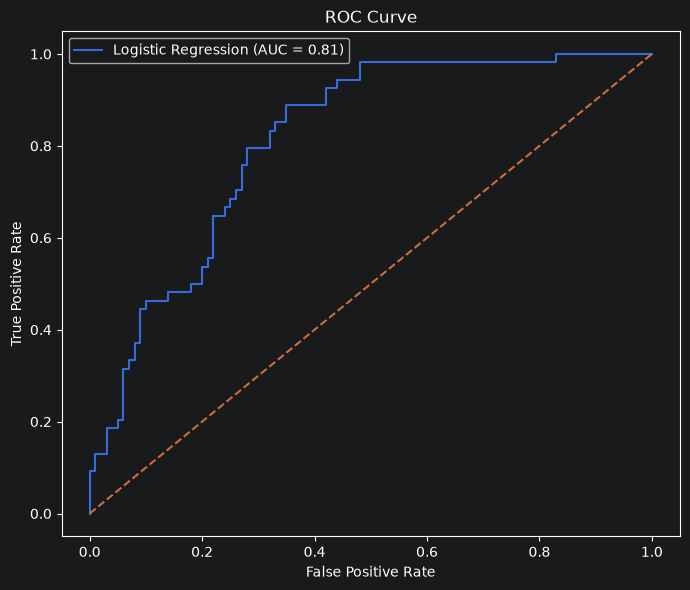

In [33]:
plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

============================================================
12. INTERPRETATION OF MODEL COEFFICIENTS
============================================================

In [34]:
logistic_model = model.named_steps["logistic_regression"]

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

In [36]:
coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

In [37]:
coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

In [38]:
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 60)


LOGISTIC REGRESSION COEFFICIENTS


In [39]:
print(coefficients[["Feature", "Coefficient"]].to_string(index=False))

                 Feature  Coefficient
                 Glucose     1.182567
                     BMI     0.688652
             Pregnancies     0.377446
DiabetesPedigreeFunction     0.233337
                     Age     0.147794
                 Insulin    -0.066119
           BloodPressure    -0.044111
           SkinThickness     0.028321


============================================================
13. SAVE TRAINED MODEL
============================================================

In [40]:
joblib.dump(
    model,
    "logistic_model.pkl"
)

['logistic_model.pkl']

In [41]:
print("\n" + "=" * 60)
print("MODEL SAVED")
print("=" * 60)


MODEL SAVED


In [42]:
print("\nSaved file: logistic_model.pkl")
print("\nReady for Streamlit deployment!")


Saved file: logistic_model.pkl

Ready for Streamlit deployment!
